# Processing the data (PyTorch)

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [12]:
# !pip install datasets evaluate transformers[sentencepiece]
# !pip install --upgrade pip
# !pip install torch
# !pip install transformers[torch]
# !pip install scikit-learn
# !pip install matplotlib

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 92.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


In [2]:
from datasets import load_dataset
import csv

# 1. Define the column names according to the LIAR dataset description
col_names = [
    "id", "label_text", "statement", "subject", "speaker", 
    "job_title", "state_info", "party_affiliation", 
    "barely_true_counts", "false_counts", "half_true_counts", 
    "mostly_true_counts", "pants_on_fire_counts", "context"
]

# 2. Load local files
raw_datasets = load_dataset(
    "csv", 
    data_files={
        "train": "/home/onyxia/work/Stat_App/Data/train.tsv", 
        "validation": "/home/onyxia/work/Stat_App/Data/valid.tsv", 
        "test": "/home/onyxia/work/Stat_App/Data/test.tsv"
    }, 
    delimiter="\t", 
    column_names=col_names,
    quoting=csv.QUOTE_NONE
)

# 3. Create a mapping for the labels (Text -> Integer)
label_mapping = {
    'pants-fire': 0, 
    'false': 1, 
    'barely-true': 2, 
    'half-true': 3, 
    'mostly-true': 4, 
    'true': 5
}

def map_labels(example):
    return {'label': label_mapping[example['label_text']]}

raw_datasets = raw_datasets.map(map_labels)

print(raw_datasets)

/home/onyxia/work/venv_sa/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 10269
    })
    validation: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 1284
    })
    test: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 1283
    })
})


In [3]:
from transformers import AutoTokenizer, DataCollatorWithPadding

checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(example):
    return tokenizer(example["statement"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

# cols_to_keep = ["input_ids", "attention_mask", "label"]
# tokenized_datasets = tokenized_datasets.remove_columns(
#     [c for c in tokenized_datasets["train"].column_names if c not in cols_to_keep]
# )

# Formatage pour PyTorch
#tokenized_datasets.set_format("torch")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# FINE TUNING

In [ ]:
import numpy as np
import evaluate
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification

# 1. Charger la métrique "accuracy" (Précision)
# On utilise 'accuracy' car c'est une classification standard
metric = evaluate.load("accuracy")

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    # On prend l'index de la plus haute probabilité (argmax) pour trouver la classe prédite (0 à 5)
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 2. Configurer les hyperparamètres d'entraînement
training_args = TrainingArguments(
    output_dir="liar-bert-finetuned", # Dossier où le modèle sera sauvegardé
    eval_strategy="epoch",            # Évaluer le modèle à la fin de chaque époque
    save_strategy="epoch",            # Sauvegarder le checkpoint à la fin de chaque époque
    learning_rate=2e-5,               # Vitesse d'apprentissage recommandée pour BERT
    per_device_train_batch_size=16,   # Taille des lots (baissez à 8 si erreur de mémoire GPU)
    per_device_eval_batch_size=16,
    num_train_epochs=25,               # Nombre de fois que le modèle voit tout le dataset (3)
    weight_decay=0.01,
    load_best_model_at_end=True,      # À la fin, garder la meilleure version (pas forcément la dernière)
)

# 3. Charger le modèle vierge (Pre-trained) avec 6 labels
checkpoint = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=6)

# 4. Initialiser le Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,             # Passe le tokenizer pour qu'il gère le padding final si besoin
    data_collator=data_collator,     # Votre collator défini précédemment
    compute_metrics=compute_metrics, # La fonction définie plus haut
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_19769/1482900898.py:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.724400,1.696027,0.246885
2,1.637800,1.665978,0.277259
3,1.532200,1.787949,0.271028
4,1.164200,1.904268,0.264019
5,1.018800,1.976053,0.267134


TrainOutput(global_step=3210, training_loss=1.3784623856113707, metrics={'train_runtime': 491.8774, 'train_samples_per_second': 104.386, 'train_steps_per_second': 6.526, 'total_flos': 1169513086367808.0, 'train_loss': 1.3784623856113707, 'epoch': 5.0})

In [17]:
print("--- Évaluation finale sur le jeu de TEST ---")
# Le Trainer a une méthode dédiée pour lancer le calcul des métriques sur un dataset donné
test_results = trainer.evaluate(tokenized_datasets["test"])
print(test_results)

--- Évaluation finale sur le jeu de TEST ---


{'eval_loss': 1.6717913150787354, 'eval_accuracy': 0.2782540919719408, 'eval_runtime': 3.4295, 'eval_samples_per_second': 374.107, 'eval_steps_per_second': 23.619, 'epoch': 5.0}


In [18]:
# Sauvegarde le modèle final et le tokenizer dans le dossier
trainer.save_model("liar-bert-finetuned-final")
tokenizer.save_pretrained("liar-bert-finetuned-final")
print("Modèle final sauvegardé avec succès.")

Modèle final sauvegardé avec succès.


In [19]:
import torch

# Fonction pour tester une phrase
def predict_fake_news(text):
    # 1. Préparer le texte
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    
    # 2. Envoyer sur le même appareil que le modèle (GPU ou CPU)
    device = trainer.model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 3. Prédiction
    with torch.no_grad():
        outputs = trainer.model(**inputs)
    
    # 4. Convertir les logits en probabilités
    logits = outputs.logits
    predicted_class_id = logits.argmax().item()
    
    # Retrouver le label texte grâce à votre dictionnaire inversé
    # On inverse votre dictionnaire label_mapping
    id2label = {v: k for k, v in label_mapping.items()}
    return id2label[predicted_class_id]

# Testons !
fake_sentence = "The earth is completely flat and supported by a giant turtle."
real_sentence = "The sky is blue and water is wet."

print(f"Phrase 1: {predict_fake_news(fake_sentence)}")
print(f"Phrase 2: {predict_fake_news(real_sentence)}")

Phrase 1: false
Phrase 2: false


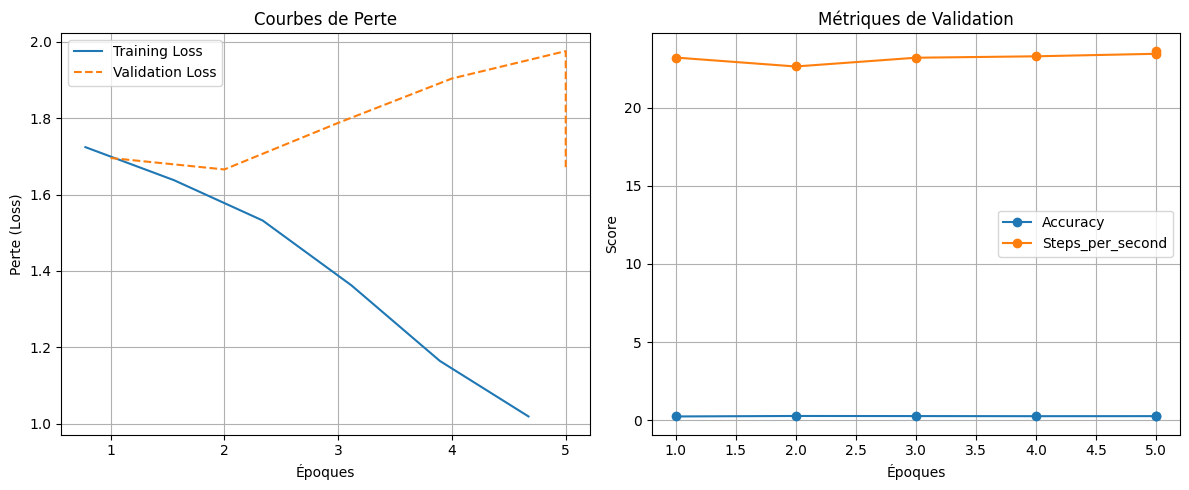

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_learning_curves(trainer):
    # 1. Récupération de l'historique des logs
    # C'est une liste de dictionnaires, ex: [{'loss': 0.5, 'step': 10}, {'eval_loss': 0.4, 'step': 10}]
    log_history = trainer.state.log_history
    
    # 2. Conversion en DataFrame Pandas pour faciliter la manipulation
    df = pd.DataFrame(log_history)
    
    # 3. Séparation des logs d'entraînement (loss) et de validation (eval_loss)
    # Les logs d'entrainement ont une colonne 'loss', ceux de validation 'eval_loss'
    train_logs = df[df['loss'].notna()].set_index('epoch')
    eval_logs = df[df['eval_loss'].notna()].set_index('epoch')
    
    # 4. Création du graphique
    plt.figure(figsize=(12, 5))
    
    # --- Courbe de Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(train_logs['loss'], label='Training Loss', color='tab:blue')
    if not eval_logs.empty:
        plt.plot(eval_logs['eval_loss'], label='Validation Loss', color='tab:orange', linestyle='--')
    plt.xlabel('Époques')
    plt.ylabel('Perte (Loss)')
    plt.title('Courbes de Perte')
    plt.legend()
    plt.grid(True)
    
    # --- Courbe de Métriques (Accuracy ou F1) ---
    # On cherche s'il y a 'eval_accuracy' ou 'eval_f1' dans les logs
    metrics_to_plot = [col for col in eval_logs.columns if 'eval_' in col and 'loss' not in col and 'runtime' not in col and 'samples' not in col]
    
    if metrics_to_plot:
        plt.subplot(1, 2, 2)
        for metric in metrics_to_plot:
            # On nettoie le nom (ex: 'eval_accuracy' -> 'Accuracy')
            label_name = metric.replace('eval_', '').capitalize()
            plt.plot(eval_logs[metric], label=label_name, marker='o')
        
        plt.xlabel('Époques')
        plt.ylabel('Score')
        plt.title('Métriques de Validation')
        plt.legend()
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# --- UTILISATION ---
# Une fois l'entraînement fini, lancez simplement :
plot_learning_curves(trainer)